In [2]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('..')

from src.data_loader import load_stratified_sample
from src.features import engineer_features
from src.analyzer import get_top_n_per_category, summary_pivot, size_interaction

In [3]:
df = load_stratified_sample()
df_reliable = engineer_features(df)

print(f"df: {df.shape}")
print(f"df_reliable: {df_reliable.shape}")

Cache ditemukan, load langsung dari ..\data\wm811k_v2.pkl
Cache ditemukan, load langsung dari ..\data\wm811k_v3_reliable.pkl
df: (811457, 9)
df_reliable: (809424, 25)


In [4]:
top3_per_category = get_top_n_per_category(df_reliable, n=3)
top3_per_category.to_pickle('../data/top3_per_category.pkl')

print(f"top3_per_category: {top3_per_category.shape}")
print(top3_per_category[['density_global', 'density_center', 'density_edge']])

top3_per_category: (27, 7)
                          density_global  density_center  density_edge
failureType_clean                                                     
Center            573           0.727142        0.961776      0.397924
                  1097          0.717783        0.967941      0.366782
                  1959          0.706983        0.964242      0.346021
Donut             4674          0.678411        0.792593      0.561457
                  4640          0.651032        0.641221      0.660517
                  4689          0.637524        0.779555      0.457701
Edge-Loc          6035          0.746124        0.797872      0.683761
                  7851          0.719493        0.713996      0.725469
                  7533          0.719444        0.753311      0.676471
Edge-Ring         13835         0.451005        0.289786      0.632000
                  17890         0.437186        0.282660      0.610667
                  15906         0.432161        0.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch
from pathlib import Path

RUN ID KALI INI: 2880


NameError: name 'categories' is not defined

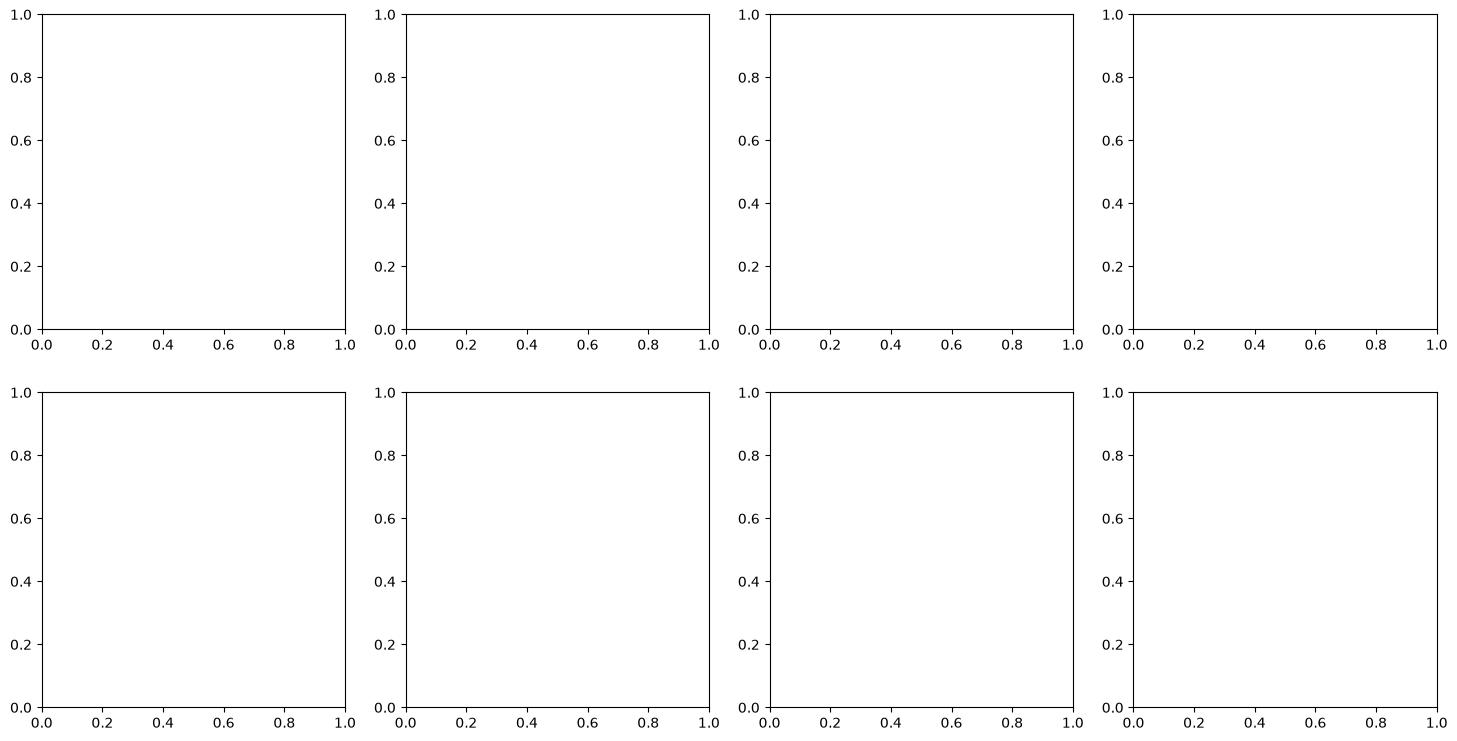

In [6]:
import random
run_id = random.randint(1000, 9999)
print("RUN ID KALI INI:", run_id)

plt.close('all')

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, cat in enumerate(categories):
    sample = top3_per_category.loc[cat].iloc[0]
    wm = sample['waferMap']
    sns.heatmap(wm, cmap=cmap, norm=norm, cbar=False, square=True,
                xticklabels=False, yticklabels=False, ax=axes[i])
    axes[i].set_title(f"{cat}", fontsize=11)

fig.suptitle(f'Wafer Map Defect Gallery \u2014 RUN {run_id}', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

Identik dgn wm_check? True
Hash wm_dari_loop: 9e853fb7e9e620e9cf4b9418827e8238
Hash wm_check:     9e853fb7e9e620e9cf4b9418827e8238


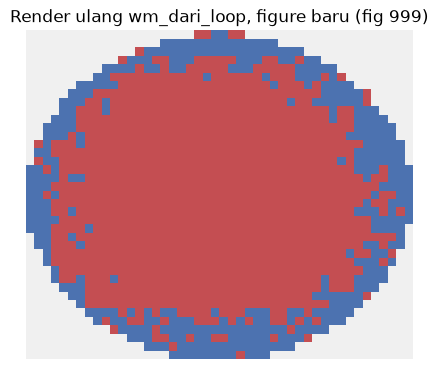

In [9]:
import numpy as np
import hashlib

wm_dari_loop = top3_per_category.loc['Center'].iloc[0]['waferMap']

# 1. Bandingkan bit-per-bit dengan array hasil isolasi sebelumnya
print("Identik dgn wm_check?", np.array_equal(wm_dari_loop, wm_check))
print("Hash wm_dari_loop:", hashlib.md5(wm_dari_loop.tobytes()).hexdigest())
print("Hash wm_check:    ", hashlib.md5(wm_check.tobytes()).hexdigest())

# 2. Render array ini di figure BENAR-BENAR baru (nomor eksplisit beda,
#    biar tidak mungkin numpang state dari fig Cell 4)
fig_isolasi2 = plt.figure(999, figsize=(5, 5))
sns.heatmap(wm_dari_loop, cmap=cmap, norm=norm, cbar=False, square=True,
            xticklabels=False, yticklabels=False)
plt.title("Render ulang wm_dari_loop, figure baru (fig 999)")
plt.show()

In [10]:
# Apa data yang SEBENARNYA dipegang oleh axes[0] (panel "Center" di grid)?
data_di_axes0 = axes[0].collections[0].get_array()
data_di_axes0 = np.asarray(data_di_axes0).reshape(wm_dari_loop.shape)

print("Shape data di axes[0]:", data_di_axes0.shape)
print("Checksum data di axes[0]:", data_di_axes0.sum())
print("Identik dgn wm_dari_loop (array yg benar)?", np.array_equal(data_di_axes0, wm_dari_loop))

# Kalau BEDA, tampilkan juga posisi pixel yang beda
if not np.array_equal(data_di_axes0, wm_dari_loop):
    diff_mask = data_di_axes0 != wm_dari_loop
    print("Jumlah pixel yang beda:", diff_mask.sum(), "dari total", diff_mask.size)

Shape data di axes[0]: (39, 46)
Checksum data di axes[0]: 2399
Identik dgn wm_dari_loop (array yg benar)? True
